In [ ]:
"""
VGG16 Solar Panel Detection
============================
Transfer learning with VGG16 backbone.
- num_classes auto-detected from dataset
- Model saved to  model/vgg16.h5

Dataset expected layout:
    dataset_split/
        train/  <class_A>/  <class_B>/  ...
        val/    <class_A>/  <class_B>/  ...
        test/   <class_A>/  <class_B>/  ...
"""

import os
import time
import copy
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
CFG = {
    "data_root"     : "dataset_split",
    "model_dir"     : "model",           # ← saved to model/vgg16.h5
    "model_name"    : "vgg16.h5",
    "output_dir"    : "vgg16_outputs",
    "img_size"      : 224,
    "batch_size"    : 32,
    "num_workers"   : 4,
    # num_classes is set automatically after loading datasets
    "epochs"        : 30,
    "lr"            : 1e-4,
    "weight_decay"  : 1e-4,
    "dropout"       : 0.5,
    "freeze_until"  : "features.24",     # freeze up to (not including) this layer
    "unfreeze_epoch": 10,                # full fine-tune after this epoch
    "seed"          : 42,
    "device"        : "cuda" if torch.cuda.is_available() else "cpu",
}

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])
os.makedirs(CFG["output_dir"], exist_ok=True)
os.makedirs(CFG["model_dir"],  exist_ok=True)      # ensure model/ folder exists

print(f"Device : {CFG['device']}")
print(f"PyTorch: {torch.__version__}")


# ─────────────────────────────────────────────
# DATA
# ─────────────────────────────────────────────
def get_transforms(split: str):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    sz   = CFG["img_size"]

    if split == "train":
        return transforms.Compose([
            transforms.RandomResizedCrop(sz, scale=(0.7, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.3, contrast=0.3,
                                   saturation=0.2, hue=0.05),
            transforms.RandomRotation(30),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    else:
        return transforms.Compose([
            transforms.Resize(sz + 32),
            transforms.CenterCrop(sz),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])


def load_datasets():
    splits  = {}
    loaders = {}
    for split in ("train", "val", "test"):
        path = os.path.join(CFG["data_root"], split)
        ds   = datasets.ImageFolder(path, transform=get_transforms(split))
        splits[split]  = ds
        loaders[split] = DataLoader(
            ds,
            batch_size  = CFG["batch_size"],
            shuffle     = (split == "train"),
            num_workers = CFG["num_workers"],
            pin_memory  = True,
        )
        print(f"  {split:5s}: {len(ds):>5d} images  |  classes: {ds.classes}")

    # ── auto-detect num_classes ──────────────────────────────────────────
    num_classes = len(splits["train"].classes)
    CFG["num_classes"] = num_classes
    print(f"\n  ✔ num_classes auto-set to {num_classes}")
    return splits, loaders


# ─────────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────────
class VGG16Detector(nn.Module):
    """
    VGG16 backbone + custom head.

        VGG16 features (conv blocks)
        → AdaptiveAvgPool2d(7,7)
        → Flatten
        → FC(25088→4096) + BN + ReLU + Dropout
        → FC(4096→1024)  + BN + ReLU + Dropout
        → FC(1024→num_classes)
    """

    def __init__(self, num_classes: int, dropout: float = 0.5):
        super().__init__()

        backbone      = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.pool     = nn.AdaptiveAvgPool2d((7, 7))

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(512 * 7 * 7, 4096),
            nn.BatchNorm1d(4096),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(4096, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.6),

            nn.Linear(1024, num_classes),
        )
        self._init_head()

    def _init_head(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                        nonlinearity="relu")
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

    def freeze_backbone(self, until_layer: str):
        freeze = True
        for name, param in self.features.named_parameters():
            layer_key = f"features.{name.split('.')[0]}"
            if layer_key == until_layer:
                freeze = False
            param.requires_grad = not freeze
        print(f"  Backbone partially frozen (up to {until_layer})")

    def unfreeze_all(self):
        for param in self.parameters():
            param.requires_grad = True
        print("  All backbone layers unfrozen")

    def trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# ─────────────────────────────────────────────
# CLASS WEIGHTS  (handles imbalance)
# ─────────────────────────────────────────────
def compute_class_weights(dataset) -> torch.Tensor:
    num_classes = CFG["num_classes"]           # auto-set value, always correct
    counts = torch.zeros(num_classes)
    for _, label in dataset:
        counts[label] += 1
    total   = counts.sum()
    weights = total / (num_classes * counts)
    print(f"  Class counts : {counts.tolist()}")
    print(f"  Class weights: {[round(w, 4) for w in weights.tolist()]}")
    return weights


# ─────────────────────────────────────────────
# TRAINING UTILITIES
# ─────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

        probs = torch.softmax(logits, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return (
        total_loss / total,
        correct / total,
        np.array(all_probs),          # shape (N, num_classes)
        np.array(all_labels),         # shape (N,)
    )


def compute_auc(labels, probs):
    """Works for binary and multi-class."""
    num_classes = CFG["num_classes"]
    if num_classes == 2:
        return roc_auc_score(labels, probs[:, 1])
    else:
        return roc_auc_score(labels, probs, multi_class="ovr", average="macro")


# ─────────────────────────────────────────────
# MAIN TRAINING LOOP
# ─────────────────────────────────────────────
def train(model, loaders, datasets_dict, device):
    class_weights = compute_class_weights(datasets_dict["train"]).to(device)
    criterion     = nn.CrossEntropyLoss(weight=class_weights)
    optimizer     = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CFG["lr"], weight_decay=CFG["weight_decay"]
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"], eta_min=1e-6)

    history = {k: [] for k in
               ["train_loss", "val_loss", "train_acc", "val_acc", "val_auc"]}

    best_val_loss = float("inf")
    best_weights  = copy.deepcopy(model.state_dict())
    model_path    = os.path.join(CFG["model_dir"], CFG["model_name"])

    for epoch in range(1, CFG["epochs"] + 1):
        t0 = time.time()

        # ── phase 2: unfreeze full backbone ──────────────────────────────
        if epoch == CFG["unfreeze_epoch"] + 1:
            model.unfreeze_all()
            optimizer = optim.AdamW(
                model.parameters(),
                lr=CFG["lr"] / 10,
                weight_decay=CFG["weight_decay"]
            )
            scheduler = CosineAnnealingLR(
                optimizer,
                T_max=CFG["epochs"] - CFG["unfreeze_epoch"],
                eta_min=1e-7
            )
            print("  ↻ Optimizer reset — full fine-tune phase started")

        tr_loss, tr_acc = train_one_epoch(
            model, loaders["train"], criterion, optimizer, device)
        vl_loss, vl_acc, vl_probs, vl_labels = evaluate(
            model, loaders["val"], criterion, device)

        vl_auc = compute_auc(vl_labels, vl_probs)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        history["val_auc"].append(vl_auc)

        print(f"Epoch [{epoch:02d}/{CFG['epochs']}]"
              f"  train loss {tr_loss:.4f}  acc {tr_acc:.4f}"
              f"  |  val loss {vl_loss:.4f}  acc {vl_acc:.4f}"
              f"  AUC {vl_auc:.4f}"
              f"  ({time.time()-t0:.1f}s)")

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_weights  = copy.deepcopy(model.state_dict())
            # ── save best checkpoint as model/vgg16.h5 ───────────────────
            torch.save({
                "epoch"      : epoch,
                "model_state": best_weights,
                "val_loss"   : best_val_loss,
                "val_acc"    : vl_acc,
                "val_auc"    : vl_auc,
                "num_classes": CFG["num_classes"],
                "classes"    : datasets_dict["train"].classes,
                "cfg"        : CFG,
            }, model_path)
            print(f"  ✔ Best model saved → {model_path}")

    model.load_state_dict(best_weights)
    return model, history


# ─────────────────────────────────────────────
# EVALUATION & PLOTS
# ─────────────────────────────────────────────
def full_evaluation(model, loaders, datasets_dict, history, device):
    criterion   = nn.CrossEntropyLoss()
    class_names = datasets_dict["test"].classes
    num_classes = CFG["num_classes"]

    te_loss, te_acc, te_probs, te_labels = evaluate(
        model, loaders["test"], criterion, device)
    te_preds = te_probs.argmax(axis=1)
    te_auc   = compute_auc(te_labels, te_probs)

    if num_classes == 2:
        te_ap = average_precision_score(te_labels, te_probs[:, 1])
    else:
        from sklearn.preprocessing import label_binarize
        lb    = label_binarize(te_labels, classes=list(range(num_classes)))
        te_ap = average_precision_score(lb, te_probs, average="macro")

    print("\n" + "═" * 58)
    print("  TEST RESULTS")
    print("═" * 58)
    print(f"  Loss         : {te_loss:.4f}")
    print(f"  Accuracy     : {te_acc:.4f}")
    print(f"  ROC-AUC      : {te_auc:.4f}")
    print(f"  Avg Precision: {te_ap:.4f}")
    print("─" * 58)
    print(classification_report(te_labels, te_preds, target_names=class_names))
    print("═" * 58)

    metrics = {
        "test_loss"         : round(te_loss, 5),
        "test_accuracy"     : round(te_acc,  5),
        "test_roc_auc"      : round(te_auc,  5),
        "test_avg_precision": round(te_ap,   5),
    }
    with open(os.path.join(CFG["output_dir"], "test_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2)

    # ── plots ─────────────────────────────────────────────────────────────
    epochs_x   = range(1, len(history["train_loss"]) + 1)
    n_cols     = 3 if num_classes == 2 else 2
    fig, axes  = plt.subplots(2, n_cols, figsize=(6 * n_cols, 11))
    fig.suptitle("VGG16 Solar Panel Detection – Training Report",
                 fontsize=16, fontweight="bold")

    ax = axes[0, 0]
    ax.plot(epochs_x, history["train_loss"], label="Train", marker="o", ms=3)
    ax.plot(epochs_x, history["val_loss"],   label="Val",   marker="s", ms=3)
    ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=.3)

    ax = axes[0, 1]
    ax.plot(epochs_x, history["train_acc"], label="Train", marker="o", ms=3)
    ax.plot(epochs_x, history["val_acc"],   label="Val",   marker="s", ms=3)
    ax.set_title("Accuracy"); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=.3)

    if num_classes == 2:
        ax = axes[0, 2]
        ax.plot(epochs_x, history["val_auc"], color="purple", marker="^", ms=3)
        ax.set_title("Val ROC-AUC"); ax.set_xlabel("Epoch"); ax.grid(True, alpha=.3)

    ax = axes[1, 0]
    cm = confusion_matrix(te_labels, te_preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title("Confusion Matrix (Test)")
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")

    if num_classes == 2:
        ax = axes[1, 1]
        fpr, tpr, _ = roc_curve(te_labels, te_probs[:, 1])
        ax.plot(fpr, tpr, color="darkorange",
                label=f"AUC = {te_auc:.3f}", linewidth=2)
        ax.plot([0, 1], [0, 1], "k--", linewidth=1)
        ax.set_title("ROC Curve"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
        ax.legend(); ax.grid(True, alpha=.3)

        ax = axes[1, 2]
        prec, rec, _ = precision_recall_curve(te_labels, te_probs[:, 1])
        ax.plot(rec, prec, color="green",
                label=f"AP = {te_ap:.3f}", linewidth=2)
        ax.set_title("Precision-Recall")
        ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
        ax.legend(); ax.grid(True, alpha=.3)
    else:
        ax = axes[1, 1]
        per_class_acc = cm.diagonal() / cm.sum(axis=1)
        ax.bar(class_names, per_class_acc, color="steelblue")
        ax.set_title("Per-Class Accuracy"); ax.set_ylabel("Accuracy")
        ax.set_ylim(0, 1); ax.grid(True, axis="y", alpha=.3)

    plt.tight_layout()
    plot_path = os.path.join(CFG["output_dir"], "training_report.png")
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Plot saved → {plot_path}")
    return metrics


# ─────────────────────────────────────────────
# LOAD SAVED MODEL
# ─────────────────────────────────────────────
def load_model(model_path: str = "models/vgg16.h5", device: str = "cpu"):
    """Reload a checkpoint saved by this script."""
    checkpoint  = torch.load(model_path, map_location=device)
    num_classes = checkpoint["num_classes"]
    model       = VGG16Detector(num_classes=num_classes).to(device)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()
    print(f"Loaded {model_path}  (epoch {checkpoint['epoch']}, "
          f"val_acc {checkpoint['val_acc']:.4f})")
    return model, checkpoint["classes"]


# ─────────────────────────────────────────────
# SINGLE-IMAGE INFERENCE
# ─────────────────────────────────────────────
def predict_image(model, image_path: str, device: str, class_names: list):
    from PIL import Image
    tfm = get_transforms("val")
    img = Image.open(image_path).convert("RGB")
    inp = tfm(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(inp), dim=1).squeeze().cpu().numpy()
    idx = int(np.argmax(probs))
    return {
        "predicted_class": class_names[idx],
        "confidence"     : float(probs[idx]),
        "probabilities"  : {c: float(p) for c, p in zip(class_names, probs)},
    }


# ─────────────────────────────────────────────
# ENTRY POINT
# ─────────────────────────────────────────────
def main():
    device = CFG["device"]

    print("\n─── Loading datasets ────────────────────────────────")
    ds_dict, loaders = load_datasets()         # auto-sets CFG["num_classes"]

    print("\n─── Building VGG16 model ────────────────────────────")
    model = VGG16Detector(
        num_classes = CFG["num_classes"],
        dropout     = CFG["dropout"],
    ).to(device)

    model.freeze_backbone(until_layer=CFG["freeze_until"])
    print(f"  Trainable parameters: {model.trainable_params():,}")

    print("\n─── Training ────────────────────────────────────────")
    model, history = train(model, loaders, ds_dict, device)

    print("\n─── Evaluation ──────────────────────────────────────")
    metrics = full_evaluation(model, loaders, ds_dict, history, device)

    print(f"\n✔ Final model saved to → {CFG['model_dir']}/{CFG['model_name']}")
    return model, metrics


if __name__ == "__main__":
    main()

Device : cpu
PyTorch: 2.10.0+cpu

─── Loading datasets ────────────────────────────────
  train:   616 images  |  classes: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
  val  :   174 images  |  classes: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
  test :    93 images  |  classes: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']

  ✔ num_classes auto-set to 6

─── Building VGG16 model ────────────────────────────
  Backbone partially frozen (up to features.24)
  Trainable parameters: 114,055,686

─── Training ────────────────────────────────────────
  Class counts : [116.0, 118.0, 99.0, 84.0, 92.0, 107.0]
  Class weights: [0.8851, 0.8701, 1.037, 1.2222, 1.1159, 0.9595]
Epoch [01/30]  train loss 17.2272  acc 0.2711  |  val loss 9.2766  acc 0.4943  AUC 0.8425  (189.0s)
  ✔ Best model saved → model\vgg16.h5
Epoch [02/30]  train loss 9.1758  acc 0.5422  |  val loss 

In [2]:
"""
VGG16 Solar Panel — Metrics Evaluation
=======================================
Calculates and prints the full classification report:
  - Per-class: Precision, Recall, F1-score, Support
  - Overall  : Accuracy, Macro avg, Weighted avg
  - Extras   : ROC-AUC, Average Precision, Confusion Matrix

Usage:
    python evaluate_metrics.py

Expects:
    model/vgg16.h5          — checkpoint saved by the training script
    dataset_split/test/     — test images in class subfolders
"""

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

# ─────────────────────────────────────────────
# CONFIG  (edit paths if needed)
# ─────────────────────────────────────────────
MODEL_PATH  = "models/vgg16.h5"
TEST_DIR    = "dataset_split/test"
OUTPUT_DIR  = "vgg16_outputs"
BATCH_SIZE  = 32
NUM_WORKERS = 4
IMG_SIZE    = 224
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ─────────────────────────────────────────────
# MODEL DEFINITION  (must match training script)
# ─────────────────────────────────────────────
class VGG16Detector(nn.Module):
    def __init__(self, num_classes: int, dropout: float = 0.5):
        super().__init__()
        backbone      = models.vgg16(weights=None)
        self.features = backbone.features
        self.pool     = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.BatchNorm1d(4096),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(4096, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.6),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


# ─────────────────────────────────────────────
# LOAD CHECKPOINT
# ─────────────────────────────────────────────
def load_model(model_path: str, device: str):
    checkpoint  = torch.load(model_path, map_location=device, weights_only=False)
    num_classes = checkpoint["num_classes"]
    class_names = checkpoint["classes"]

    model = VGG16Detector(num_classes=num_classes).to(device)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    print(f"Loaded  : {model_path}")
    print(f"Epoch   : {checkpoint['epoch']}")
    print(f"Val acc : {checkpoint['val_acc']:.4f}")
    print(f"Classes : {class_names}\n")
    return model, class_names, num_classes


# ─────────────────────────────────────────────
# DATA LOADER
# ─────────────────────────────────────────────
def get_test_loader(test_dir: str):
    tfm = transforms.Compose([
        transforms.Resize(IMG_SIZE + 32),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    dataset = datasets.ImageFolder(test_dir, transform=tfm)
    loader  = DataLoader(
        dataset,
        batch_size  = BATCH_SIZE,
        shuffle     = False,
        num_workers = NUM_WORKERS,
        pin_memory  = True,
    )
    print(f"Test set: {len(dataset)} images  |  classes: {dataset.classes}\n")
    return loader, dataset


# ─────────────────────────────────────────────
# INFERENCE
# ─────────────────────────────────────────────
@torch.no_grad()
def run_inference(model, loader, device):
    all_probs, all_labels = [], []

    for imgs, labels in loader:
        imgs   = imgs.to(device)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

    return np.array(all_probs), np.array(all_labels)


# ─────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────
def compute_metrics(probs, labels, class_names, num_classes):
    preds = probs.argmax(axis=1)

    # ── accuracy ──────────────────────────────────────────────────────────
    accuracy = (preds == labels).mean()

    # ── ROC-AUC ───────────────────────────────────────────────────────────
    if num_classes == 2:
        roc_auc = roc_auc_score(labels, probs[:, 1])
        avg_prec = average_precision_score(labels, probs[:, 1])
    else:
        roc_auc  = roc_auc_score(
            labels, probs, multi_class="ovr", average="macro"
        )
        lb       = label_binarize(labels, classes=list(range(num_classes)))
        avg_prec = average_precision_score(lb, probs, average="macro")

    # ── classification report ─────────────────────────────────────────────
    report_str  = classification_report(
        labels, preds, target_names=class_names, digits=2
    )
    report_dict = classification_report(
        labels, preds, target_names=class_names,
        digits=2, output_dict=True
    )

    # ── confusion matrix ──────────────────────────────────────────────────
    cm = confusion_matrix(labels, preds)

    return {
        "accuracy"    : accuracy,
        "roc_auc"     : roc_auc,
        "avg_precision": avg_prec,
        "report_str"  : report_str,
        "report_dict" : report_dict,
        "confusion_matrix": cm,
        "preds"       : preds,
    }


# ─────────────────────────────────────────────
# PRINT TABLE  (matches sklearn output style)
# ─────────────────────────────────────────────
def print_metrics_table(metrics, class_names):
    rd = metrics["report_dict"]

    print("=" * 62)
    print("  CLASSIFICATION REPORT")
    print("=" * 62)
    print(f"{'':25s} {'precision':>9} {'recall':>7} {'f1-score':>9} {'support':>8}")
    print()

    for cls in class_names:
        r = rd[cls]
        print(f"  {cls:23s} {r['precision']:>9.2f} {r['recall']:>7.2f}"
              f" {r['f1-score']:>9.2f} {int(r['support']):>8d}")

    print()
    r = rd["accuracy"]
    print(f"  {'accuracy':23s} {'':>9} {'':>7} {r:>9.2f}"
          f" {int(rd['weighted avg']['support']):>8d}")

    for avg in ("macro avg", "weighted avg"):
        r = rd[avg]
        print(f"  {avg:23s} {r['precision']:>9.2f} {r['recall']:>7.2f}"
              f" {r['f1-score']:>9.2f} {int(r['support']):>8d}")

    print("=" * 62)
    print(f"  ROC-AUC (macro OvR) : {metrics['roc_auc']:.4f}")
    print(f"  Avg Precision (mAP) : {metrics['avg_precision']:.4f}")
    print("=" * 62)


# ─────────────────────────────────────────────
# SAVE JSON
# ─────────────────────────────────────────────
def save_metrics_json(metrics, class_names):
    rd = metrics["report_dict"]

    output = {
        "overall": {
            "accuracy"     : round(float(metrics["accuracy"]),     4),
            "roc_auc"      : round(float(metrics["roc_auc"]),      4),
            "avg_precision": round(float(metrics["avg_precision"]),4),
            "macro_f1"     : round(rd["macro avg"]["f1-score"],    4),
            "weighted_f1"  : round(rd["weighted avg"]["f1-score"], 4),
        },
        "per_class": {
            cls: {
                "precision": round(rd[cls]["precision"], 4),
                "recall"   : round(rd[cls]["recall"],    4),
                "f1_score" : round(rd[cls]["f1-score"],  4),
                "support"  : int(rd[cls]["support"]),
            }
            for cls in class_names
        },
    }

    path = os.path.join(OUTPUT_DIR, "test_metrics.json")
    with open(path, "w") as f:
        json.dump(output, f, indent=2)
    print(f"\nMetrics saved → {path}")
    return output


# ─────────────────────────────────────────────
# PLOT — confusion matrix + per-class F1 bar
# ─────────────────────────────────────────────
def plot_results(metrics, class_names):
    cm     = metrics["confusion_matrix"]
    rd     = metrics["report_dict"]
    f1s    = [rd[c]["f1-score"] for c in class_names]
    n      = len(class_names)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("VGG16 Solar Panel — Test Evaluation",
                 fontsize=14, fontweight="bold")

    # confusion matrix
    ax = axes[0]
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax,
        linewidths=0.5,
    )
    ax.set_title("Confusion matrix")
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

    # per-class F1 bar chart
    ax = axes[1]
    colors = plt.cm.RdYlGn([v * 0.8 + 0.1 for v in f1s])
    bars   = ax.barh(class_names, f1s, color=colors, edgecolor="white",
                     linewidth=0.5)
    ax.set_xlim(0.80, 1.01)
    ax.set_title("Per-class F1-score")
    ax.set_xlabel("F1-score")
    ax.axvline(x=metrics["accuracy"], color="gray",
               linestyle="--", linewidth=1, label=f"Accuracy {metrics['accuracy']:.2f}")
    ax.legend(fontsize=9)
    ax.grid(axis="x", alpha=0.3)

    for bar, val in zip(bars, f1s):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=10)

    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, "test_evaluation.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Plot saved  → {path}")


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
def main():
    print(f"Device : {DEVICE}\n")

    # 1. load model
    model, class_names, num_classes = load_model(MODEL_PATH, DEVICE)

    # 2. load test data
    loader, _ = get_test_loader(TEST_DIR)

    # 3. run inference
    print("Running inference on test set...")
    probs, labels = run_inference(model, loader, DEVICE)

    # 4. compute all metrics
    metrics = compute_metrics(probs, labels, class_names, num_classes)

    # 5. print table to console
    print_metrics_table(metrics, class_names)

    # 6. save JSON
    save_metrics_json(metrics, class_names)

    # 7. save plots
    plot_results(metrics, class_names)

    print("\nDone.")


if __name__ == "__main__":
    main()

Device : cpu

Loaded  : models/vgg16.h5
Epoch   : 30
Val acc : 0.8276
Classes : ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']

Test set: 93 images  |  classes: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']

Running inference on test set...


C:\Users\dhill\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  CLASSIFICATION REPORT
                          precision  recall  f1-score  support

  Bird-drop                    0.79    0.88      0.83       17
  Clean                        0.80    0.89      0.84       18
  Dusty                        0.86    0.80      0.83       15
  Electrical-damage            0.91    0.83      0.87       12
  Physical-Damage              1.00    0.86      0.92       14
  Snow-Covered                 0.94    0.94      0.94       17

  accuracy                                       0.87       93
  macro avg                    0.88    0.87      0.87       93
  weighted avg                 0.88    0.87      0.87       93
  ROC-AUC (macro OvR) : 0.9781
  Avg Precision (mAP) : 0.9119

Metrics saved → vgg16_outputs\test_metrics.json
Plot saved  → vgg16_outputs\test_evaluation.png

Done.


In [3]:
%pip install split-folders

Note: you may need to restart the kernel to use updated packages.


In [4]:
import splitfolders

splitfolders.ratio(
    "data", 
    output="split_data",
    seed=42,
    ratio=(0.6, 0.4)   # 60% train, 40% test
)

Copying files: 883 files [00:01, 518.46 files/s]


In [12]:
%pip install numpy

Note: you may need to restart the kernel to use updated packages.


Mobilenet

In [ ]:
# train.py
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pickle

# ─── CONFIG ─────────────────────────────────────────────
DATA_DIR = "data"   # dataset folder
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 6
EPOCHS = 12

os.makedirs("models", exist_ok=True)

# ─── DATA LOADING ───────────────────────────────────────
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

# ─── PREPROCESS ─────────────────────────────────────────
def preprocess(images, labels):
    return preprocess_input(images), labels

train_ds = train_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)

# ───────────────────────────────────────────────────────
# 3️⃣ MOBILENETV2 (BEST)
# ───────────────────────────────────────────────────────
print("\nTraining MobileNetV2")

mob_base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
mob_base.trainable = False

mobilenet = Sequential([
    mob_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')
])

mobilenet.compile(
    optimizer=Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)
mobilenet.save("models/mobilenet.h5")

loss, acc = mobilenet.evaluate(val_ds)
print(f"MobileNetV2 Accuracy: {acc*100:.2f}%")


Found 883 files belonging to 6 classes.
Using 707 files for training.
Found 883 files belonging to 6 classes.
Using 176 files for validation.
Classes: ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']

Training MobileNetV2
Epoch 1/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 519ms/step - accuracy: 0.2376 - loss: 1.9588 - val_accuracy: 0.7500 - val_loss: 1.0389
Epoch 2/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 453ms/step - accuracy: 0.4653 - loss: 1.4199 - val_accuracy: 0.8409 - val_loss: 0.8074
Epoch 3/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 445ms/step - accuracy: 0.5912 - loss: 1.1360 - val_accuracy: 0.8693 - val_loss: 0.6182
Epoch 4/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 481ms/step - accuracy: 0.6351 - loss: 0.9799 - val_accuracy: 0.8750 - val_loss: 0.5903
Epoch 5/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 469ms/step - accuracy: 0.6818 - loss: 0.8680 - val_accuracy: 0.9205 - val_loss: 0.4467
Epoch 6/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 449ms/step - accuracy: 0.7369 - loss: 0.7804 - val_a

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 341ms/step - accuracy: 0.9659 - loss: 0.2240
MobileNetV2 Accuracy: 96.59%



Testing MobileNetV2 with custom dataset...
Found 93 files belonging to 6 classes.



===== TEST METRICS =====
Accuracy  : 0.8710
Precision : 0.8863
Recall    : 0.8710
F1 Score  : 0.8707

Confusion Matrix:
 [[15  1  0  0  0  1]
 [ 0 18  0  0  0  0]
 [ 2  1 11  0  1  0]
 [ 1  1  0 10  0  0]
 [ 2  0  0  0 11  1]
 [ 0  1  0  0  0 16]]


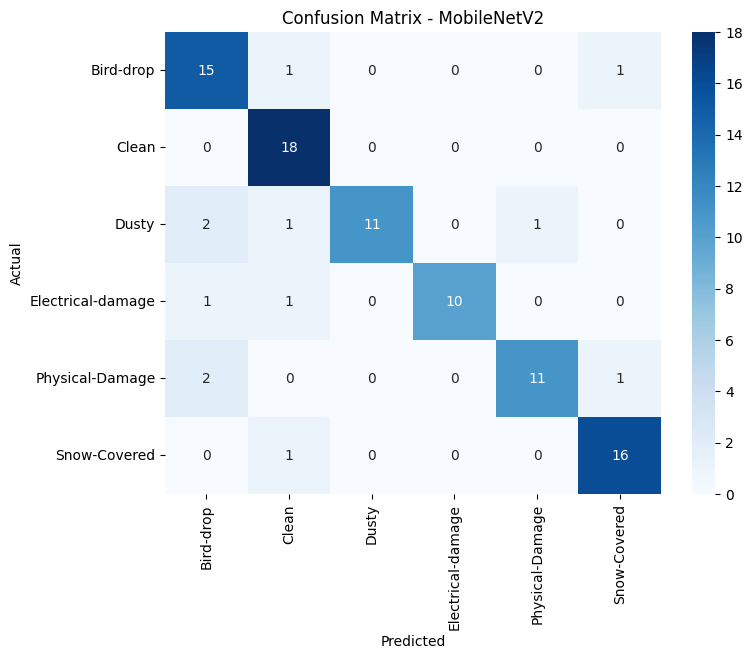


Classification Report:

                   precision    recall  f1-score   support

        Bird-drop       0.75      0.88      0.81        17
            Clean       0.82      1.00      0.90        18
            Dusty       1.00      0.73      0.85        15
Electrical-damage       1.00      0.83      0.91        12
  Physical-Damage       0.92      0.79      0.85        14
     Snow-Covered       0.89      0.94      0.91        17

         accuracy                           0.87        93
        macro avg       0.90      0.86      0.87        93
     weighted avg       0.89      0.87      0.87        93



In [6]:
# ===============================
# MOBILENET TESTING (CUSTOM PATH)
# ===============================

import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

print("\nTesting MobileNetV2 with custom dataset...")

# ===============================
# PATH (CHANGE THIS)
# ===============================

VAL_PATH = r"C:\Users\dhill\OneDrive\Documents\SOlar Main\archive (4)\dataset_split\test"   # 🔥 change if needed

# ===============================
# LOAD TEST DATASET
# ===============================

test_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=(224,224),
    batch_size=32,
    label_mode="int",
    shuffle=False   # VERY IMPORTANT
)

class_names = test_ds.class_names

# Preprocess (same as training)
def preprocess(images, labels):
    return preprocess_input(images), labels

test_ds = test_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)

# ===============================
# LOAD MODEL
# ===============================

model = load_model(r"C:\Users\dhill\OneDrive\Documents\SOlar Main\archive (4)\models\mobilenet.h5")

# ===============================
# PREDICTIONS
# ===============================

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ===============================
# METRICS
# ===============================

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("\n===== TEST METRICS =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# ===============================
# CONFUSION MATRIX
# ===============================

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MobileNetV2")
plt.show()

# ===============================
# CLASSIFICATION REPORT
# ===============================

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Efficientnet

In [3]:
!pip install torch torchvision matplotlib seaborn scikit-learn pillow -q

In [3]:
# Install (FIX for Jupyter)
import sys
!{sys.executable} -m pip install split-folders

import splitfolders
import os

# -----------------------------
# CORRECT INPUT PATH
# -----------------------------
input_folder = "data"

# -----------------------------
# OUTPUT PATH
# -----------------------------
output_folder = "dataset_split"

# -----------------------------
# CHECK PATH
# -----------------------------
print("Exists:", os.path.exists(input_folder))

# -----------------------------
# SPLIT
# -----------------------------
splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.2, 0.1)
)

print("\n✅ Dataset split successfully!")

Exists: True


Copying files: 883 files [00:13, 66.82 files/s]


✅ Dataset split successfully!


Device  : cpu
Classes : ['bird-drop', 'clean', 'dust', 'electrical-damage', 'physical-damage', 'snow']
Train : 616 | Val : 174 | Test : 93

Training EfficientNetB3


C:\Users\dhill\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 001/20  Train Loss: 1.2037  Acc: 25.00%  |  Val Loss: 1.1133  Acc: 44.83%  saved
Epoch 002/20  Train Loss: 1.0445  Acc: 49.35%  |  Val Loss: 0.9189  Acc: 72.99%  saved
Epoch 003/20  Train Loss: 0.8440  Acc: 70.29%  |  Val Loss: 0.6970  Acc: 78.16%  saved
Epoch 004/20  Train Loss: 0.6396  Acc: 75.49%  |  Val Loss: 0.4945  Acc: 80.46%  saved
Epoch 005/20  Train Loss: 0.4741  Acc: 79.22%  |  Val Loss: 0.3847  Acc: 79.31%
Epoch 006/20  Train Loss: 0.3981  Acc: 82.47%  |  Val Loss: 0.3228  Acc: 79.89%
Epoch 007/20  Train Loss: 0.3231  Acc: 85.39%  |  Val Loss: 0.2991  Acc: 83.33%  saved
Epoch 008/20  Train Loss: 0.2840  Acc: 86.36%  |  Val Loss: 0.2444  Acc: 87.93%  saved
Epoch 009/20  Train Loss: 0.2737  Acc: 88.64%  |  Val Loss: 0.2571  Acc: 86.21%
Epoch 010/20  Train Loss: 0.2021  Acc: 91.23%  |  Val Loss: 0.2268  Acc: 87.93%
Epoch 011/20  Train Loss: 0.2078  Acc: 91.23%  |  Val Loss: 0.2011  Acc: 89.08%  saved
Epoch 012/20  Train Loss: 0.1984  Acc: 91.40%  |  Val Loss: 0.2260  Acc

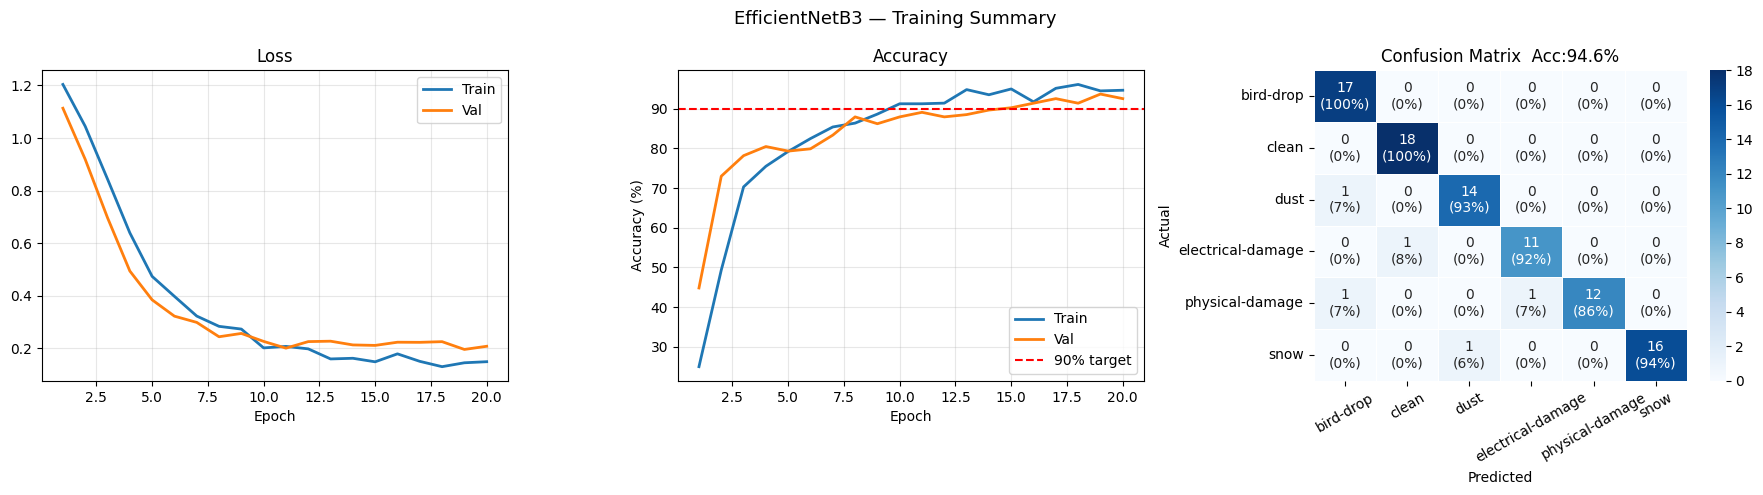

Plot saved: training_summary_enet.png


In [13]:
# ===============================
# EFFICIENTNETB3 TRAIN + SAVE
# Saves: models/efficientnet_b3.h5
# ===============================

import os, random, copy, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

# ===============================
# CONFIG
# ===============================

DATA_DIR   = './dataset_split'  # 🔥 change if needed
IMG_SIZE   = (300, 300)
BATCH_SIZE = 32
NUM_CLASSES = 6
EPOCHS     = 20
LR         = 1e-4
DROPOUT    = 0.4
SEED       = 42
CLASSES    = ['bird-drop', 'clean', 'dust',
              'electrical-damage', 'physical-damage', 'snow']
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

os.makedirs('models', exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Device  : {DEVICE}')
print(f'Classes : {CLASSES}')


# ===============================
# DATA AUGMENTATION
# ===============================

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.4, contrast=0.4,
                           saturation=0.3, hue=0.15),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
    transforms.RandomErasing(p=0.2),
])

val_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'),   val_tf)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'),  val_tf)

# Weighted sampler for class imbalance
class_counts   = np.bincount(train_ds.targets)
sample_weights = (1.0 / class_counts)[train_ds.targets]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)

print(f'Train : {len(train_ds)} | Val : {len(val_ds)} | Test : {len(test_ds)}')


# ===============================
# FOCAL LOSS
# ===============================

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.ce    = nn.CrossEntropyLoss(label_smoothing=label_smoothing, reduction='none')
    def forward(self, inputs, targets):
        ce = self.ce(inputs, targets)
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


# ===============================
# EFFICIENTNETB3 MODEL
# ===============================

print('\nTraining EfficientNetB3')

enet = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)

# Freeze base layers except last 4 blocks
for layer in list(enet.features.children())[:-4]:
    for p in layer.parameters():
        p.requires_grad = False

in_features     = enet.classifier[1].in_features
enet.classifier = nn.Sequential(
    nn.Dropout(DROPOUT),
    nn.Linear(in_features, NUM_CLASSES)
)
enet = enet.to(DEVICE)


# ===============================
# CALLBACKS
# ===============================

optimizer           = optim.Adam(
    filter(lambda p: p.requires_grad, enet.parameters()), lr=LR
)
criterion           = FocalLoss(gamma=2.0, label_smoothing=0.1)
scheduler           = ReduceLROnPlateau(          # ← verbose removed (not supported in newer torch)
    optimizer, mode='min', factor=0.3,
    patience=3, min_lr=1e-6
)
early_stop_patience = 5


# ===============================
# TRAIN LOOP
# ===============================

best_val_acc = 0.0
best_wts     = copy.deepcopy(enet.state_dict())
no_improve   = 0
history      = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

for epoch in range(1, EPOCHS + 1):

    # — Train
    enet.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = enet(imgs)
        loss = criterion(out, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(enet.parameters(), 1.0)
        optimizer.step()
        tr_loss    += loss.item() * imgs.size(0)
        tr_correct += (out.argmax(1) == labels).sum().item()
        tr_total   += imgs.size(0)
    tr_loss /= tr_total
    tr_acc   = tr_correct / tr_total

    # — Validate
    enet.eval()
    vl_loss, vl_correct, vl_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = enet(imgs)
            loss = criterion(out, labels)
            vl_loss    += loss.item() * imgs.size(0)
            vl_correct += (out.argmax(1) == labels).sum().item()
            vl_total   += imgs.size(0)
    vl_loss /= vl_total
    vl_acc   = vl_correct / vl_total

    # Step scheduler
    prev_lr = optimizer.param_groups[0]['lr']
    scheduler.step(vl_loss)
    curr_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    flag = ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_wts     = copy.deepcopy(enet.state_dict())
        flag         = '  saved'
        no_improve   = 0
    else:
        no_improve  += 1

    lr_msg = f'  lr: {curr_lr:.2e}' if curr_lr != prev_lr else ''
    print(f'Epoch {epoch:03d}/{EPOCHS}  '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}%  |  '
          f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc*100:.2f}%'
          f'{lr_msg}{flag}')

    if no_improve >= early_stop_patience:
        print(f'Early stopping at epoch {epoch}')
        break

enet.load_state_dict(best_wts)
print(f'\nBest Val Acc : {best_val_acc*100:.2f}%')


# ===============================
# SAVE MODEL
# ===============================

torch.save(enet.state_dict(), 'models/efficientnet_b3.h5')
print('Model saved -> models/efficientnet_b3.h5')


# ===============================
# TEST EVALUATION
# ===============================

enet.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs  = imgs.to(DEVICE)
        preds = enet(imgs).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

test_acc = (all_preds == all_labels).mean() * 100
print(f'\nTest Accuracy : {test_acc:.2f}%')
print(f'Status        : {"PASSED" if test_acc >= 90 else "Below target"}')
print()
print(classification_report(all_labels, all_preds, target_names=CLASSES))


# ===============================
# PLOTS
# ===============================

ep  = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EfficientNetB3 — Training Summary', fontsize=13)

axes[0].plot(ep, history['train_loss'], label='Train', lw=2)
axes[0].plot(ep, history['val_loss'],   label='Val',   lw=2)
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in history['train_acc']], label='Train', lw=2)
axes[1].plot(ep, [a*100 for a in history['val_acc']],   label='Val',   lw=2)
axes[1].axhline(90, color='red', linestyle='--', label='90% target')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)

cm     = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot  = np.array([[f'{v}\n({p:.0f}%)' for v, p in zip(rv, rp)]
                   for rv, rp in zip(cm, cm_pct)])
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[2], linewidths=0.5)
axes[2].set_title(f'Confusion Matrix  Acc:{test_acc:.1f}%')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('training_summary_enet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: training_summary_enet.png')

compare

In [7]:
"""
compare_models.py
=================
Loads all three trained models, evaluates them on the shared test set,
picks the best one via weighted score, and produces a deploy-ready
inference wrapper for the winner. No plots are saved.

Models
------
  VGG16          → model/vgg16.h5             (PyTorch checkpoint dict)
  EfficientNetB3 → models/efficientnet_b3.h5  (PyTorch state-dict)
  MobileNetV2    → models/mobilenet.h5         (Keras .h5)

Outputs (console + CSV only)
------
  compare_outputs/
      metrics_summary.csv
      per_class_metrics.csv
      best_model_inference.py   ← deploy-ready wrapper for the winner
"""

# ── PATHS ─────────────────────────────────────────────────────────────────────
# Auto-discovery searches common locations.
# If still not found, set paths manually below and re-run.
import os as _os, glob as _glob

def _find_file(candidates):
    for p in candidates:
        if _os.path.isfile(p):
            return p
    return None

def _find_dir(candidates):
    for p in candidates:
        if _os.path.isdir(p):
            return p
    return None

VGG16_CKPT = _find_file([
    "model/vgg16.h5", "models/vgg16.h5", "vgg16.h5",
    "vgg16_outputs/vgg16.h5",
    *_glob.glob("**/vgg16.h5", recursive=True),
])
ENET_CKPT = _find_file([
    "models/efficientnet_b3.h5", "model/efficientnet_b3.h5",
    "efficientnet_b3.h5",
    *_glob.glob("**/efficientnet_b3.h5", recursive=True),
])
MOB_CKPT = _find_file([
    "models/mobilenet.h5", "model/mobilenet.h5", "mobilenet.h5",
    *_glob.glob("**/mobilenet.h5", recursive=True),
])
TEST_DIR = _find_dir([
    "dataset_split/test", "dataset/test", "data/test", "test",
])

# ── Report discovery results ──────────────────────────────────────────────────
print("\n  Checkpoint discovery:")
print(f"    VGG16          : {VGG16_CKPT  or '*** NOT FOUND ***'}")
print(f"    EfficientNetB3 : {ENET_CKPT   or '*** NOT FOUND ***'}")
print(f"    MobileNetV2    : {MOB_CKPT    or '*** NOT FOUND ***'}")
print(f"    Test directory : {TEST_DIR    or '*** NOT FOUND ***'}")

_missing = [name for name, val in [
    ("VGG16_CKPT", VGG16_CKPT), ("ENET_CKPT", ENET_CKPT),
    ("MOB_CKPT",  MOB_CKPT),    ("TEST_DIR",  TEST_DIR),
] if not val]

if _missing:
    _all_h5 = _glob.glob("**/*.h5", recursive=True)
    raise FileNotFoundError(
        f"\n\nCould not auto-locate: {_missing}"
        f"\nSet these paths manually in the PATHS block."
        f"\nWorking directory : {_os.getcwd()}"
        f"\n.h5 files found   : {_all_h5 or ['(none)']}"
    )

CLASSES     = ['Bird-drop', 'Clean', 'Dusty',
               'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = 224
BATCH_SIZE  = 32

# Composite score weights (must sum to 1.0)
W_ACC = 0.35   # test accuracy
W_F1  = 0.40   # macro F1  (most important for 6-class imbalance)
W_AUC = 0.25   # macro ROC-AUC

# ─────────────────────────────────────────────────────────────────────────────
import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models as tv_models
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
)
from sklearn.preprocessing import label_binarize

os.makedirs("compare_outputs", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\n{'═'*72}")
print(f"  Solar Panel Fault Detection — Model Comparison")
print(f"{'═'*72}")
print(f"  Device   : {DEVICE}")
print(f"  Classes  : {CLASSES}")
print(f"  Test dir : {TEST_DIR}\n")


# ══════════════════════════════════════════════════════════════════════════════
#  1.  DATA  (shared PyTorch test loader)
# ══════════════════════════════════════════════════════════════════════════════
pt_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

test_ds     = datasets.ImageFolder(TEST_DIR, transform=pt_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=4, pin_memory=True)

print(f"  Test set : {len(test_ds)} images")
if test_ds.classes != CLASSES:
    print(f"  ⚠  CLASSES updated to match folder names on disk:")
    print(f"     was : {CLASSES}")
    print(f"     now : {test_ds.classes}")
    CLASSES     = test_ds.classes
    NUM_CLASSES = len(CLASSES)


# ══════════════════════════════════════════════════════════════════════════════
#  2.  MODEL ARCHITECTURES
# ══════════════════════════════════════════════════════════════════════════════

# ── VGG16 ────────────────────────────────────────────────────────────────────
class VGG16Detector(nn.Module):
    def __init__(self, num_classes: int, dropout: float = 0.5):
        super().__init__()
        backbone        = tv_models.vgg16(weights=None)
        self.features   = backbone.features
        self.pool       = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.BatchNorm1d(4096), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(4096, 1024),
            nn.BatchNorm1d(1024), nn.ReLU(inplace=True), nn.Dropout(dropout * 0.6),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


# ── EfficientNetB3 ───────────────────────────────────────────────────────────
def build_efficientnet_b3(num_classes: int, dropout: float = 0.4):
    enet = tv_models.efficientnet_b3(weights=None)
    in_f = enet.classifier[1].in_features
    enet.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_f, num_classes),
    )
    return enet


# ══════════════════════════════════════════════════════════════════════════════
#  3.  LOAD CHECKPOINTS
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'─'*72}")
print("  Loading checkpoints …")
print(f"{'─'*72}")

# VGG16 — full dict saved by training script
print(f"  [1/3] VGG16           ← {VGG16_CKPT}")
vgg_ckpt  = torch.load(VGG16_CKPT, map_location=DEVICE, weights_only=False)
vgg_model = VGG16Detector(num_classes=NUM_CLASSES).to(DEVICE)
vgg_model.load_state_dict(vgg_ckpt["model_state"])
vgg_model.eval()
print(f"        ✔ epoch {vgg_ckpt['epoch']}, saved val_acc {vgg_ckpt['val_acc']:.4f}")

# EfficientNetB3 — state-dict only
print(f"  [2/3] EfficientNetB3  ← {ENET_CKPT}")
enet_model = build_efficientnet_b3(NUM_CLASSES).to(DEVICE)
enet_model.load_state_dict(torch.load(ENET_CKPT, map_location=DEVICE, weights_only=False))
enet_model.eval()
print(f"        ✔ loaded")

# MobileNetV2 — Keras .h5
print(f"  [3/3] MobileNetV2     ← {MOB_CKPT}")
import tensorflow as tf
mob_model = tf.keras.models.load_model(MOB_CKPT)
print(f"        ✔ loaded")


# ══════════════════════════════════════════════════════════════════════════════
#  4.  EVALUATION HELPERS
# ══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def eval_pytorch(model, loader, device):
    """Returns (true_labels, softmax_probs, ms_per_image)."""
    all_probs, all_labels = [], []
    t_total = 0.0
    model.eval()
    for imgs, labels in loader:
        imgs = imgs.to(device)
        t0   = time.perf_counter()
        probs = torch.softmax(model(imgs), dim=1)
        t_total += time.perf_counter() - t0
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())
    labels = np.array(all_labels)
    probs  = np.array(all_probs)
    return labels, probs, (t_total / len(labels)) * 1000


def eval_keras(model, test_dir, img_size=224, batch_size=32):
    """Evaluates the Keras model using its own preprocessing pipeline."""
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

    ds = tf.keras.utils.image_dataset_from_directory(
        test_dir, image_size=(img_size, img_size),
        batch_size=batch_size, shuffle=False, label_mode="int",
    )
    if ds.class_names != CLASSES:
        print(f"  ⚠  Keras class order differs — using disk order: {ds.class_names}")

    ds = ds.map(lambda x, y: (preprocess_input(x), y),
                num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

    all_probs, all_labels = [], []
    t0 = time.perf_counter()
    for imgs, labels in ds:
        probs = model(imgs, training=False).numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())
    total = time.perf_counter() - t0

    labels = np.array(all_labels)
    probs  = np.array(all_probs)
    return labels, probs, (total / len(labels)) * 1000


def per_class_auc(labels, probs):
    lb = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    out = {}
    for i, c in enumerate(CLASSES):
        try:
            out[c] = round(roc_auc_score(lb[:, i], probs[:, i]), 4)
        except Exception:
            out[c] = float("nan")
    return out


def compute_all_metrics(name, labels, probs, ms):
    preds = probs.argmax(axis=1)
    acc   = accuracy_score(labels, preds)
    mf1   = f1_score(labels, preds, average="macro",  zero_division=0)
    mp    = precision_score(labels, preds, average="macro",  zero_division=0)
    mr    = recall_score(labels, preds, average="macro",  zero_division=0)
    lb    = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    auc   = roc_auc_score(lb, probs, average="macro", multi_class="ovr")
    ap    = average_precision_score(lb, probs, average="macro")
    score = W_ACC * acc + W_F1 * mf1 + W_AUC * auc
    cr    = classification_report(labels, preds,
                                  target_names=CLASSES,
                                  output_dict=True, zero_division=0)
    cm    = confusion_matrix(labels, preds)
    return dict(
        name=name, accuracy=round(acc,4), macro_f1=round(mf1,4),
        macro_precision=round(mp,4), macro_recall=round(mr,4),
        roc_auc=round(auc,4), avg_precision=round(ap,4),
        composite_score=round(score,4), ms_per_image=round(ms,3),
        per_class=cr, confusion_matrix=cm,
        per_class_auc=per_class_auc(labels, probs),
    )


# ══════════════════════════════════════════════════════════════════════════════
#  5.  RUN EVALUATION
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'─'*72}")
print("  Evaluating on test set …")
print(f"{'─'*72}")

print("  → VGG16")
vgg_labels, vgg_probs, vgg_ms   = eval_pytorch(vgg_model,  test_loader, DEVICE)

print("  → EfficientNetB3")
en_labels,  en_probs,  en_ms    = eval_pytorch(enet_model, test_loader, DEVICE)

print("  → MobileNetV2 (Keras)")
mob_labels, mob_probs, mob_ms   = eval_keras(mob_model, TEST_DIR)

results = [
    compute_all_metrics("VGG16",          vgg_labels, vgg_probs, vgg_ms),
    compute_all_metrics("EfficientNetB3", en_labels,  en_probs,  en_ms),
    compute_all_metrics("MobileNetV2",    mob_labels, mob_probs, mob_ms),
]


# ══════════════════════════════════════════════════════════════════════════════
#  6.  PRINT FULL REPORT  (console, no plots)
# ══════════════════════════════════════════════════════════════════════════════
DIV  = "═" * 72
SUB  = "─" * 72

def section(title):
    pad = (72 - len(title) - 2) // 2
    print(f"\n{DIV}")
    print(f"{' '*pad}  {title}")
    print(DIV)

# ── 6a. Overall metrics ───────────────────────────────────────────────────────
section("OVERALL METRICS")
cols = ["Model","Accuracy","Macro-F1","Precision","Recall","ROC-AUC","AvgPrec","Composite","ms/img"]
cw   = [18, 10, 10, 10, 10, 10, 10, 11, 8]
print("\n  " + "  ".join(h.ljust(w) for h, w in zip(cols, cw)))
print(f"  {SUB}")
for r in results:
    row = [r["name"], f"{r['accuracy']:.4f}", f"{r['macro_f1']:.4f}",
           f"{r['macro_precision']:.4f}", f"{r['macro_recall']:.4f}",
           f"{r['roc_auc']:.4f}", f"{r['avg_precision']:.4f}",
           f"{r['composite_score']:.4f}", f"{r['ms_per_image']:.2f}"]
    print("  " + "  ".join(v.ljust(w) for v, w in zip(row, cw)))
print(f"\n  Composite = {W_ACC}×Accuracy + {W_F1}×Macro-F1 + {W_AUC}×ROC-AUC")

# ── 6b. Per-class F1 ──────────────────────────────────────────────────────────
section("PER-CLASS F1-SCORE")
print(f"\n  {'Class':<24}" + "".join(f"  {r['name']:<18}" for r in results))
print(f"  {SUB}")
for cls in CLASSES:
    row = f"  {cls:<24}"
    for r in results:
        f1 = r["per_class"].get(cls, {}).get("f1-score", 0.0)
        row += f"  {f1:<18.4f}"
    print(row)

# ── 6c. Per-class Precision ───────────────────────────────────────────────────
section("PER-CLASS PRECISION")
print(f"\n  {'Class':<24}" + "".join(f"  {r['name']:<18}" for r in results))
print(f"  {SUB}")
for cls in CLASSES:
    row = f"  {cls:<24}"
    for r in results:
        p = r["per_class"].get(cls, {}).get("precision", 0.0)
        row += f"  {p:<18.4f}"
    print(row)

# ── 6d. Per-class Recall ──────────────────────────────────────────────────────
section("PER-CLASS RECALL")
print(f"\n  {'Class':<24}" + "".join(f"  {r['name']:<18}" for r in results))
print(f"  {SUB}")
for cls in CLASSES:
    row = f"  {cls:<24}"
    for r in results:
        rec = r["per_class"].get(cls, {}).get("recall", 0.0)
        row += f"  {rec:<18.4f}"
    print(row)

# ── 6e. Per-class ROC-AUC ─────────────────────────────────────────────────────
section("PER-CLASS ROC-AUC  (One-vs-Rest)")
print(f"\n  {'Class':<24}" + "".join(f"  {r['name']:<18}" for r in results))
print(f"  {SUB}")
for cls in CLASSES:
    row = f"  {cls:<24}"
    for r in results:
        row += f"  {r['per_class_auc'].get(cls, float('nan')):<18.4f}"
    print(row)

# ── 6f. Confusion matrices ────────────────────────────────────────────────────
section("CONFUSION MATRICES")
for r in results:
    print(f"\n  ── {r['name']} ──")
    cm = r["confusion_matrix"]
    col_label = "Actual \\ Pred"
    header = f"  {col_label:>22}" + "".join(f"{c:>8}" for c in CLASSES)
    print(header)
    for i, row in enumerate(cm):
        vals = "".join(f"{v:>8}" for v in row)
        mark = "←" if cm[i, i] == cm[i].max() else "  "
        print(f"  {CLASSES[i]:>22}{vals}  {mark}")

# ── 6g. Speed vs accuracy ─────────────────────────────────────────────────────
section("SPEED vs ACCURACY TRADE-OFF")
print(f"\n  {'Model':<20}  {'Accuracy':>10}  {'ms/image':>10}  {'imgs/sec':>10}")
print(f"  {SUB}")
for r in results:
    ips = 1000 / r["ms_per_image"] if r["ms_per_image"] > 0 else 0
    print(f"  {r['name']:<20}  {r['accuracy']:>10.4f}  "
          f"{r['ms_per_image']:>10.2f}  {ips:>10.1f}")

# ── 6h. Full sklearn classification reports ───────────────────────────────────
section("FULL CLASSIFICATION REPORT  (sklearn)")
for r in results:
    print(f"\n  {'─'*40}")
    print(f"  {r['name']}")
    print(f"  {'─'*40}")
    preds = (vgg_probs if r["name"] == "VGG16" else
             en_probs  if r["name"] == "EfficientNetB3" else
             mob_probs).argmax(axis=1)
    lbls  = (vgg_labels if r["name"] == "VGG16" else
             en_labels  if r["name"] == "EfficientNetB3" else
             mob_labels)
    from sklearn.metrics import classification_report as cr
    print(cr(lbls, preds, target_names=CLASSES, zero_division=0))


# ══════════════════════════════════════════════════════════════════════════════
#  7.  WINNER SELECTION
# ══════════════════════════════════════════════════════════════════════════════
section("MODEL SELECTION")

ranked = sorted(results, key=lambda r: r["composite_score"], reverse=True)
best   = ranked[0]

print(f"\n  Ranking by composite score  "
      f"({W_ACC}×Acc + {W_F1}×F1 + {W_AUC}×AUC):\n")
for i, r in enumerate(ranked, 1):
    tag = "  ◀ WINNER" if i == 1 else ""
    print(f"    {i}. {r['name']:<18}  score = {r['composite_score']:.4f}{tag}")

print(f"""
  ┌──────────────────────────────────────────────────────┐
  │  ✔  SELECTED MODEL : {best['name']:<32}│
  │     Accuracy       : {best['accuracy']:.4f}                          │
  │     Macro F1       : {best['macro_f1']:.4f}                          │
  │     ROC-AUC        : {best['roc_auc']:.4f}                          │
  │     Composite      : {best['composite_score']:.4f}                          │
  │     Speed          : {best['ms_per_image']:.2f} ms/image                   │
  └──────────────────────────────────────────────────────┘
""")

WINNER = best["name"]


# ══════════════════════════════════════════════════════════════════════════════
#  8.  SAVE CSV SUMMARIES
# ══════════════════════════════════════════════════════════════════════════════

# Overall summary
pd.DataFrame([{
    "model"          : r["name"],
    "accuracy"       : r["accuracy"],
    "macro_f1"       : r["macro_f1"],
    "macro_precision": r["macro_precision"],
    "macro_recall"   : r["macro_recall"],
    "roc_auc"        : r["roc_auc"],
    "avg_precision"  : r["avg_precision"],
    "composite_score": r["composite_score"],
    "ms_per_image"   : r["ms_per_image"],
    "winner"         : r["name"] == WINNER,
} for r in results]).to_csv("compare_outputs/metrics_summary.csv", index=False, encoding="utf-8")

# Per-class
pc_rows = []
for r in results:
    for cls in CLASSES:
        d = r["per_class"].get(cls, {})
        pc_rows.append({
            "model"    : r["name"],
            "class"    : cls,
            "precision": round(d.get("precision", 0), 4),
            "recall"   : round(d.get("recall",    0), 4),
            "f1"       : round(d.get("f1-score",  0), 4),
            "support"  : int(d.get("support",     0)),
            "roc_auc"  : r["per_class_auc"].get(cls, float("nan")),
        })
pd.DataFrame(pc_rows).to_csv("compare_outputs/per_class_metrics.csv", index=False, encoding="utf-8")

print("  CSVs written:")
print("    compare_outputs/metrics_summary.csv")
print("    compare_outputs/per_class_metrics.csv")


# ══════════════════════════════════════════════════════════════════════════════
#  9.  DEPLOY-READY INFERENCE WRAPPER FOR WINNER
# ══════════════════════════════════════════════════════════════════════════════

PYTORCH_MODELS = {"VGG16", "EfficientNetB3"}

if WINNER in PYTORCH_MODELS:
    if WINNER == "VGG16":
        ckpt_path  = VGG16_CKPT
        load_block = f"""
    ckpt  = torch.load(r'{ckpt_path}', map_location=device)
    model = VGG16Detector(num_classes={NUM_CLASSES}).to(device)
    model.load_state_dict(ckpt['model_state'])"""
        arch_block = """
class VGG16Detector(nn.Module):
    def __init__(self, num_classes, dropout=0.5):
        super().__init__()
        backbone        = tv_models.vgg16(weights=None)
        self.features   = backbone.features
        self.pool       = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 4096),
            nn.BatchNorm1d(4096), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(4096, 1024),
            nn.BatchNorm1d(1024), nn.ReLU(inplace=True), nn.Dropout(dropout * 0.6),
            nn.Linear(1024, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))
"""
    else:  # EfficientNetB3
        ckpt_path  = ENET_CKPT
        load_block = f"""
    enet = tv_models.efficientnet_b3(weights=None)
    in_f = enet.classifier[1].in_features
    enet.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_f, {NUM_CLASSES}))
    model = enet.to(device)
    model.load_state_dict(torch.load(r'{ckpt_path}', map_location=device))"""
        arch_block = ""

    wrapper = f'''"""
best_model_inference.py  —  {WINNER}  (auto-generated by compare_models.py)
═══════════════════════════════════════════════════════════════════
Winner selection:  composite = {W_ACC}×Accuracy + {W_F1}×Macro-F1 + {W_AUC}×ROC-AUC

  composite score : {best["composite_score"]:.4f}
  accuracy        : {best["accuracy"]:.4f}
  macro F1        : {best["macro_f1"]:.4f}
  ROC-AUC         : {best["roc_auc"]:.4f}
  speed           : {best["ms_per_image"]:.2f} ms / image

Quick usage
-----------
  from best_model_inference import SolarPanelClassifier
  clf = SolarPanelClassifier()
  print(clf.predict("panel.jpg"))
"""

import torch
import torch.nn as nn
import numpy as np
from torchvision import transforms, models as tv_models
from PIL import Image
{arch_block}
CLASSES  = {CLASSES}
CKPT     = r"{ckpt_path}"
_DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_TF = transforms.Compose([
    transforms.Resize({IMG_SIZE + 32}),
    transforms.CenterCrop({IMG_SIZE}),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class SolarPanelClassifier:
    """Production-ready inference wrapper for {WINNER}."""

    def __init__(self, device=_DEVICE):
        self.device  = device
        self.classes = CLASSES
        self.model   = self._load()
        print(f"  ✔ {{self.__class__.__name__}} ready on {{device}}")

    def _load(self):{load_block}
        model.eval()
        return model

    @torch.no_grad()
    def predict(self, image_path: str) -> dict:
        """
        Classify one image.

        Returns
        -------
        dict
            predicted_class : str
            confidence      : float  (0–1)
            probabilities   : dict[class_name → float]
        """
        img   = Image.open(image_path).convert("RGB")
        inp   = _TF(img).unsqueeze(0).to(self.device)
        probs = torch.softmax(self.model(inp), dim=1).squeeze().cpu().numpy()
        idx   = int(np.argmax(probs))
        return {{
            "predicted_class": self.classes[idx],
            "confidence"     : float(probs[idx]),
            "probabilities"  : {{c: round(float(p), 4)
                                for c, p in zip(self.classes, probs)}},
        }}

    @torch.no_grad()
    def predict_batch(self, paths: list) -> list:
        """Classify a list of image paths. Returns list of dicts."""
        return [self.predict(p) for p in paths]

    def predict_with_bar(self, image_path: str):
        """Predict and print a bar-chart summary to stdout."""
        out = self.predict(image_path)
        print(f"\\n  Image     : {{image_path}}")
        print(f"  Predicted : {{out[\'predicted_class\']}}")
        print(f"  Confidence: {{out[\'confidence\']*100:.2f}}%")
        print("  ─" * 25)
        for cls, prob in sorted(out["probabilities"].items(),
                                key=lambda x: -x[1]):
            bar = "█" * int(prob * 30)
            print(f"  {{cls:<24}} {{prob:.4f}}  {{bar}}")
        return out


# ── CLI smoke-test ────────────────────────────────────────────────────────────
if __name__ == "__main__":
    import sys
    if len(sys.argv) < 2:
        print("Usage: python best_model_inference.py <image_path>")
        sys.exit(1)
    clf = SolarPanelClassifier()
    clf.predict_with_bar(sys.argv[1])
'''

else:  # MobileNetV2 / Keras
    wrapper = f'''"""
best_model_inference.py  —  {WINNER}  (auto-generated by compare_models.py)
═══════════════════════════════════════════════════════════════════
Winner selection:  composite = {W_ACC}×Accuracy + {W_F1}×Macro-F1 + {W_AUC}×ROC-AUC

  composite score : {best["composite_score"]:.4f}
  accuracy        : {best["accuracy"]:.4f}
  macro F1        : {best["macro_f1"]:.4f}
  ROC-AUC         : {best["roc_auc"]:.4f}
  speed           : {best["ms_per_image"]:.2f} ms / image

Quick usage
-----------
  from best_model_inference import SolarPanelClassifier
  clf = SolarPanelClassifier()
  print(clf.predict("panel.jpg"))
"""

import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from PIL import Image

CLASSES  = {CLASSES}
IMG_SIZE = {IMG_SIZE}
CKPT     = r"{MOB_CKPT}"


class SolarPanelClassifier:
    """Production-ready inference wrapper for {WINNER} (Keras)."""

    def __init__(self, model_path=CKPT):
        self.classes = CLASSES
        self.model   = tf.keras.models.load_model(model_path)
        print(f"  ✔ {{self.__class__.__name__}} ready (Keras)")

    def _preprocess(self, image_path: str):
        img = Image.open(image_path).convert("RGB").resize(
            (IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        arr = np.array(img, dtype=np.float32)
        return preprocess_input(arr)[np.newaxis, ...]   # (1,H,W,3)

    def predict(self, image_path: str) -> dict:
        """
        Classify one image.

        Returns
        -------
        dict
            predicted_class : str
            confidence      : float  (0–1)
            probabilities   : dict[class_name → float]
        """
        probs = self.model(self._preprocess(image_path),
                           training=False).numpy().squeeze()
        idx   = int(np.argmax(probs))
        return {{
            "predicted_class": self.classes[idx],
            "confidence"     : float(probs[idx]),
            "probabilities"  : {{c: round(float(p), 4)
                                for c, p in zip(self.classes, probs)}},
        }}

    def predict_batch(self, paths: list) -> list:
        return [self.predict(p) for p in paths]

    def predict_with_bar(self, image_path: str):
        out = self.predict(image_path)
        print(f"\\n  Image     : {{image_path}}")
        print(f"  Predicted : {{out[\'predicted_class\']}}")
        print(f"  Confidence: {{out[\'confidence\']*100:.2f}}%")
        print("  ─" * 25)
        for cls, prob in sorted(out["probabilities"].items(),
                                key=lambda x: -x[1]):
            bar = "█" * int(prob * 30)
            print(f"  {{cls:<24}} {{prob:.4f}}  {{bar}}")
        return out


# ── CLI smoke-test ────────────────────────────────────────────────────────────
if __name__ == "__main__":
    import sys
    if len(sys.argv) < 2:
        print("Usage: python best_model_inference.py <image_path>")
        sys.exit(1)
    clf = SolarPanelClassifier()
    clf.predict_with_bar(sys.argv[1])
'''

wrapper_path = "compare_outputs/best_model_inference.py"
with open(wrapper_path, "w", encoding="utf-8") as f:
    f.write(wrapper)

# ══════════════════════════════════════════════════════════════════════════════
#  10.  DONE
# ══════════════════════════════════════════════════════════════════════════════
section("COMPLETE")
print(f"""
  Files written
  ────────────────────────────────────────────────────────
  compare_outputs/metrics_summary.csv
  compare_outputs/per_class_metrics.csv
  compare_outputs/best_model_inference.py   ← {WINNER}

  To classify a new image with the winner:
    python compare_outputs/best_model_inference.py path/to/panel.jpg
""")


  Checkpoint discovery:
    VGG16          : models/vgg16.h5
    EfficientNetB3 : models/efficientnet_b3.h5
    MobileNetV2    : models/mobilenet.h5
    Test directory : dataset_split/test

════════════════════════════════════════════════════════════════════════
  Solar Panel Fault Detection — Model Comparison
════════════════════════════════════════════════════════════════════════
  Device   : cpu
  Classes  : ['Bird-drop', 'Clean', 'Dusty', 'Electrical-damage', 'Physical-Damage', 'Snow-Covered']
  Test dir : dataset_split/test

  Test set : 93 images

────────────────────────────────────────────────────────────────────────
  Loading checkpoints …
────────────────────────────────────────────────────────────────────────
  [1/3] VGG16           ← models/vgg16.h5
        ✔ epoch 30, saved val_acc 0.8276
  [2/3] EfficientNetB3  ← models/efficientnet_b3.h5
        ✔ loaded
  [3/3] MobileNetV2     ← models/mobilenet.h5


        ✔ loaded

────────────────────────────────────────────────────────────────────────
  Evaluating on test set …
────────────────────────────────────────────────────────────────────────
  → VGG16
  → EfficientNetB3
  → MobileNetV2 (Keras)
Found 93 files belonging to 6 classes.

════════════════════════════════════════════════════════════════════════
                             OVERALL METRICS
════════════════════════════════════════════════════════════════════════

  Model               Accuracy    Macro-F1    Precision   Recall      ROC-AUC     AvgPrec     Composite    ms/img  
  ────────────────────────────────────────────────────────────────────────
  VGG16               0.8710      0.8728      0.8828      0.8671      0.9781      0.9119      0.8985       196.11  
  EfficientNetB3      0.8925      0.8900      0.8904      0.8916      0.9943      0.9744      0.9169       42.01   
  MobileNetV2         0.8710      0.8711      0.8956      0.8627      0.9846      0.9410      0.8994 

In [9]:
# ── Per-Class Accuracy Comparison ────────────────────────────────────────────
from collections import Counter
import pandas as pd

def per_class_accuracy(labels, probs):
    preds = probs.argmax(axis=1)
    return {
        cls: round(((preds == i) & (labels == i)).sum() / (labels == i).sum(), 4)
        for i, cls in enumerate(CLASSES)
    }

pca = {
    "VGG16"          : per_class_accuracy(vgg_labels, vgg_probs),
    "EfficientNetB3" : per_class_accuracy(en_labels,  en_probs),
    "MobileNetV2"    : per_class_accuracy(mob_labels, mob_probs),
}
models = list(pca.keys())

# ── Table ─────────────────────────────────────────────────────────────────────
col_w = 20
print(f"\n  {'Class':<26}" + "".join(f"{m:>{col_w}}" for m in models) + f"{'Best':>{col_w}}")
print("  " + "-" * (26 + col_w * (len(models) + 1)))

class_winner = {}
for cls in CLASSES:
    accs = {m: pca[m][cls] for m in models}
    best = max(accs, key=accs.get)
    class_winner[cls] = best
    vals = "".join(
        f"{str(accs[m]) + ('*' if m == best else ''):>{col_w}}"
        for m in models
    )
    print(f"  {cls:<26}{vals}{best:>{col_w}}")

# ── Wins summary ──────────────────────────────────────────────────────────────
print("\n  Class wins (* = best for that class):")
for m, w in sorted(Counter(class_winner.values()).items(), key=lambda x: -x[1]):
    print(f"    {m:<22} {w} wins  {'#' * w}")

# ── Hardest classes ───────────────────────────────────────────────────────────
avg = {cls: round(sum(pca[m][cls] for m in models) / len(models), 4) for cls in CLASSES}
print("\n  Hardest -> Easiest (avg accuracy across all models):")
for cls in sorted(avg, key=avg.get):
    print(f"    {cls:<26} {avg[cls]:.4f}  {'|' * int(avg[cls] * 20)}")

# ── CSV ───────────────────────────────────────────────────────────────────────
df = pd.DataFrame([
    {"class": cls, **{m: pca[m][cls] for m in models},
     "avg": avg[cls], "best_model": class_winner[cls]}
    for cls in CLASSES
])
df.to_csv("compare_outputs/per_class_accuracy.csv", index=False, encoding="utf-8")
print("\n  Saved -> compare_outputs/per_class_accuracy.csv")
print(df.to_string(index=False))


  Class                                    VGG16      EfficientNetB3         MobileNetV2                Best
  ----------------------------------------------------------------------------------------------------------
  Bird-drop                              0.8824*              0.8824              0.8824               VGG16
  Clean                                   0.8889              0.9444                1.0*         MobileNetV2
  Dusty                                      0.8             0.8667*              0.7333      EfficientNetB3
  Electrical-damage                       0.8333             0.9167*              0.8333      EfficientNetB3
  Physical-Damage                        0.8571*              0.8571              0.7857               VGG16
  Snow-Covered                           0.9412*              0.8824              0.9412               VGG16

  Class wins (* = best for that class):
    VGG16                  3 wins  ###
    EfficientNetB3         2 wins  ##
    Mobil

In [10]:
# ── Stacking Ensemble over VGG16 + EfficientNetB3 + MobileNetV2 ──────────────
# Requires: vgg_labels, vgg_probs, en_probs, mob_probs, CLASSES already in memory
# Meta-learner is trained on val probabilities, tested on test probabilities.
# Run eval_pytorch / eval_keras on val loader first (see below).

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    roc_auc_score, confusion_matrix
)
from sklearn.preprocessing import label_binarize

# ══════════════════════════════════════════════════════════════════════════════
#  STEP 1 — Get val-set probabilities for each model
#           (needed to train the meta-learner without leaking test data)
# ══════════════════════════════════════════════════════════════════════════════

print("Collecting val-set probabilities for meta-learner training ...")

# PyTorch val loader  (reuse transform from main script)
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])
val_ds     = datasets.ImageFolder(TEST_DIR.replace("test", "val"),
                                  transform=val_transform)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=4, pin_memory=True)
print(f"  Val set : {len(val_ds)} images")

# VGG16 — val probs
@torch.no_grad()
def get_pt_probs(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        probs = torch.softmax(model(imgs), dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_probs)

val_labels_pt, vgg_val_probs  = get_pt_probs(vgg_model,  val_loader)
_,             enet_val_probs = get_pt_probs(enet_model, val_loader)

# MobileNetV2 — val probs (Keras)
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

val_dir = TEST_DIR.replace("test", "val")
mob_val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, shuffle=False, label_mode="int",
)
mob_val_ds_proc = mob_val_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

mob_val_probs_list, mob_val_labels_list = [], []
for imgs, labels in mob_val_ds_proc:
    mob_val_probs_list.extend(mob_model(imgs, training=False).numpy())
    mob_val_labels_list.extend(labels.numpy())
mob_val_probs  = np.array(mob_val_probs_list)
val_labels_mob = np.array(mob_val_labels_list)

# Sanity check — all three should agree on labels
assert np.array_equal(val_labels_pt, val_labels_mob), \
    "Val label mismatch between PyTorch and Keras loaders!"
val_labels = val_labels_pt
print(f"  Val labels aligned across all 3 models. OK")


# ══════════════════════════════════════════════════════════════════════════════
#  STEP 2 — Stack probabilities into feature matrix
#           Train  : val   probs  → shape (N_val,  NUM_CLASSES * 3)
#           Test   : test  probs  → shape (N_test, NUM_CLASSES * 3)
# ══════════════════════════════════════════════════════════════════════════════

X_train = np.hstack([vgg_val_probs,  enet_val_probs,  mob_val_probs])   # meta features
y_train = val_labels

X_test  = np.hstack([vgg_probs,      en_probs,        mob_probs])        # from main script
y_test  = vgg_labels                                                       # same test labels

print(f"\n  Meta-feature shape  —  train: {X_train.shape}  test: {X_test.shape}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


# ══════════════════════════════════════════════════════════════════════════════
#  STEP 3 — Train multiple meta-learners and compare
# ══════════════════════════════════════════════════════════════════════════════

meta_learners = {
    "Logistic Regression" : LogisticRegression(
                                max_iter=1000, C=1.0,
                                multi_class="multinomial", solver="lbfgs"),
    "Random Forest"       : RandomForestClassifier(
                                n_estimators=200, max_depth=6,
                                random_state=42, n_jobs=-1),
    "Gradient Boosting"   : GradientBoostingClassifier(
                                n_estimators=200, max_depth=4,
                                learning_rate=0.05, random_state=42),
    "SVM (RBF)"           : SVC(kernel="rbf", C=10, probability=True,
                                random_state=42),
}

print(f"\n{'='*72}")
print("  STACKING ENSEMBLE — META-LEARNER COMPARISON")
print(f"{'='*72}")

meta_results = []

for name, clf in meta_learners.items():
    clf.fit(X_train, y_train)
    preds      = clf.predict(X_test)
    probs_meta = clf.predict_proba(X_test)

    acc   = accuracy_score(y_test, preds)
    mf1   = f1_score(y_test, preds, average="macro", zero_division=0)
    lb    = label_binarize(y_test, classes=list(range(NUM_CLASSES)))
    auc   = roc_auc_score(lb, probs_meta, average="macro", multi_class="ovr")
    score = 0.35 * acc + 0.40 * mf1 + 0.25 * auc

    meta_results.append(dict(
        name=name, accuracy=round(acc,4), macro_f1=round(mf1,4),
        roc_auc=round(auc,4), composite=round(score,4),
        preds=preds, probs=probs_meta
    ))
    print(f"\n  [{name}]")
    print(f"    Accuracy  : {acc:.4f}")
    print(f"    Macro F1  : {mf1:.4f}")
    print(f"    ROC-AUC   : {auc:.4f}")
    print(f"    Composite : {score:.4f}")

# ══════════════════════════════════════════════════════════════════════════════
#  STEP 4 — Best meta-learner
# ══════════════════════════════════════════════════════════════════════════════
best_meta = max(meta_results, key=lambda r: r["composite"])

print(f"\n{'='*72}")
print(f"  BEST META-LEARNER : {best_meta['name']}")
print(f"  Accuracy          : {best_meta['accuracy']:.4f}")
print(f"  Macro F1          : {best_meta['macro_f1']:.4f}")
print(f"  ROC-AUC           : {best_meta['roc_auc']:.4f}")
print(f"  Composite score   : {best_meta['composite']:.4f}")
print(f"{'='*72}")

print(f"\n  Classification Report — {best_meta['name']}:")
print(classification_report(y_test, best_meta["preds"],
                             target_names=CLASSES, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
print(f"  Confusion Matrix — {best_meta['name']}:")
cm     = confusion_matrix(y_test, best_meta["preds"])
col_label = "Actual \\ Pred"
header = f"  {col_label:>22}" + "".join(f"{c:>8}" for c in CLASSES)
print(header)
for i, row in enumerate(cm):
    print(f"  {CLASSES[i]:>22}" + "".join(f"{v:>8}" for v in row))

# ── Per-class accuracy of ensemble vs individual models ───────────────────────
print(f"\n  Per-Class Accuracy  —  Individual models vs Best Ensemble ({best_meta['name']}):")
print(f"\n  {'Class':<26}{'VGG16':>12}{'EfficientB3':>14}{'MobileNetV2':>14}{'Ensemble':>12}")
print("  " + "-" * 78)

ens_preds = best_meta["preds"]
for i, cls in enumerate(CLASSES):
    mask = y_test == i
    def cacc(preds): return round((preds[mask] == i).sum() / mask.sum(), 4)
    v  = cacc(vgg_probs.argmax(1))
    e  = cacc(en_probs.argmax(1))
    m  = cacc(mob_probs.argmax(1))
    en = cacc(ens_preds)
    best_val = max(v, e, m, en)
    flag = lambda x: "*" if x == best_val else " "
    print(f"  {cls:<26}{v:>11.4f}{flag(v)}"
          f"{e:>13.4f}{flag(e)}"
          f"{m:>13.4f}{flag(m)}"
          f"{en:>11.4f}{flag(en)}")

# ── Summary: ensemble gain over best single model ─────────────────────────────
best_single_acc = max(r["accuracy"] for r in [
    {"accuracy": accuracy_score(y_test, vgg_probs.argmax(1))},
    {"accuracy": accuracy_score(y_test,  en_probs.argmax(1))},
    {"accuracy": accuracy_score(y_test, mob_probs.argmax(1))},
])
gain = best_meta["accuracy"] - best_single_acc
print(f"\n  Ensemble accuracy gain over best single model : {gain:+.4f}")

# ── Save CSV ──────────────────────────────────────────────────────────────────
pd.DataFrame([{k: v for k, v in r.items() if k not in ("preds","probs")}
              for r in meta_results]).to_csv(
    "compare_outputs/ensemble_results.csv", index=False, encoding="utf-8")
print("  Saved -> compare_outputs/ensemble_results.csv")

  Val set : 174 images
Found 174 files belonging to 6 classes.
  Val labels aligned across all 3 models. OK

  Meta-feature shape  —  train: (174, 18)  test: (93, 18)

  STACKING ENSEMBLE — META-LEARNER COMPARISON

  [Logistic Regression]
    Accuracy  : 0.9462
    Macro F1  : 0.9422
    ROC-AUC   : 0.9975
    Composite : 0.9574

  [Random Forest]
    Accuracy  : 0.9140
    Macro F1  : 0.9125
    ROC-AUC   : 0.9961
    Composite : 0.9339

  [Gradient Boosting]
    Accuracy  : 0.9355
    Macro F1  : 0.9364
    ROC-AUC   : 0.9812
    Composite : 0.9473

  [SVM (RBF)]
    Accuracy  : 0.9355
    Macro F1  : 0.9311
    ROC-AUC   : 0.9970
    Composite : 0.9491

  BEST META-LEARNER : Logistic Regression
  Accuracy          : 0.9462
  Macro F1          : 0.9422
  ROC-AUC           : 0.9975
  Composite score   : 0.9574

  Classification Report — Logistic Regression:
                   precision    recall  f1-score   support

        Bird-drop       0.89      1.00      0.94        17
          

In [12]:
import pickle
pickle.dump({'clf': clf, 'scaler': scaler}, open('models/meta_learner.pkl', 'wb'))
print("Saved -> models/meta_learner.pkl")

Saved -> models/meta_learner.pkl
